In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

# for plotting
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
}) 

In [4]:
# paths setting
DATA_PATH = "../data/heart.csv"
SCREENSHOTS_DIR = "../screenshots"
os.makedirs(SCREENSHOTS_DIR, exist_ok=True)

In [8]:
# Load Data 
df = pd.read_csv(DATA_PATH)

print("=" * 40)
print("Datset Overview")
print("=" * 40)
print(f"Shape          : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Memory usage   : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print(f"\nColumn names   : {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
df.head()

Datset Overview
Shape          : 303 rows × 14 columns
Memory usage   : 33.3 KB

Column names   : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
target        int64
dtype: object

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [13]:
# feture descriptions useful for reporting
feature_info = {
    "age":      "Age in years (numerical)",
    "sex":      "Sex: 1=male, 0=female (categorical)",
    "cp":       "Chest pain type: 0=typical angina, 1=atypical, 2=non-anginal, 3=asymptomatic (categorical)",
    "trestbps": "Resting blood pressure in mmHg (numerical)",
    "chol":     "Serum cholesterol in mg/dl (numerical)",
    "fbs":      "Fasting blood sugar > 120 mg/dl: 1=true, 0=false (categorical)",
    "restecg":  "Resting ECG results: 0=normal, 1=ST-T abnormality, 2=LV hypertrophy (categorical)",
    "thalach":  "Maximum heart rate achieved (numerical)",
    "exang":    "Exercise induced angina: 1=yes, 0=no (categorical)",
    "oldpeak":  "ST depression induced by exercise (numerical)",
    "slope":    "Slope of peak exercise ST segment: 0=up, 1=flat, 2=down (categorical)",
    "ca":       "Number of major vessels colored by fluoroscopy: 0-4 (categorical)",
    "thal":     "Thalassemia: 0=normal, 1=fixed defect, 2=reversible defect (categorical)",
    "target":   "Heart disease: 1=present, 0=absent (TARGET)",
}
print("=" * 40)
print("FEATURE DESCRIPTIONS")
print("=" * 40)
for col, desc in feature_info.items():
    print(f"  {col:<12}: {desc}")

FEATURE DESCRIPTIONS
  age         : Age in years (numerical)
  sex         : Sex: 1=male, 0=female (categorical)
  cp          : Chest pain type: 0=typical angina, 1=atypical, 2=non-anginal, 3=asymptomatic (categorical)
  trestbps    : Resting blood pressure in mmHg (numerical)
  chol        : Serum cholesterol in mg/dl (numerical)
  fbs         : Fasting blood sugar > 120 mg/dl: 1=true, 0=false (categorical)
  restecg     : Resting ECG results: 0=normal, 1=ST-T abnormality, 2=LV hypertrophy (categorical)
  thalach     : Maximum heart rate achieved (numerical)
  exang       : Exercise induced angina: 1=yes, 0=no (categorical)
  oldpeak     : ST depression induced by exercise (numerical)
  slope       : Slope of peak exercise ST segment: 0=up, 1=flat, 2=down (categorical)
  ca          : Number of major vessels colored by fluoroscopy: 0-4 (categorical)
  thal        : Thalassemia: 0=normal, 1=fixed defect, 2=reversible defect (categorical)
  target      : Heart disease: 1=present, 0=ab

MISSING VALUE ANALYSIS
      Missing Count  Missing %
ca                4       1.32
thal              2       0.66
Total missing cells: 6


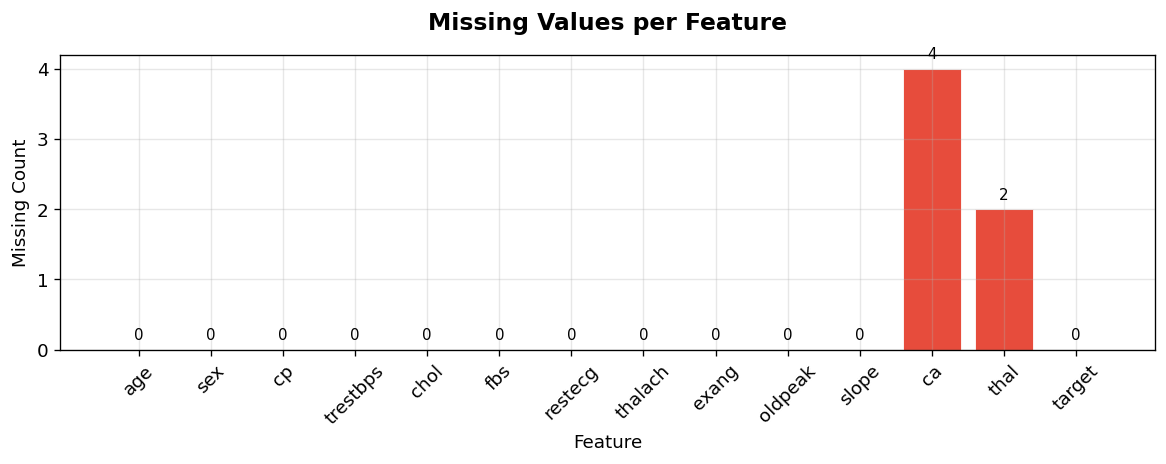

Saved: ../screenshots/eda_missing_values.png


In [17]:
# Missing value analysis
print("=" * 40)
print("MISSING VALUE ANALYSIS")
print("=" * 40)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
})
print(missing_df[missing_df["Missing Count"] > 0])

if missing.sum() == 0:
    print("No missing values found in the dataset.")
else:
    print(f"Total missing cells: {missing.sum()}")

# Visualise missing values
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#e74c3c" if v > 0 else "#2ecc71" for v in missing.values]
bars = ax.bar(missing.index, missing.values, color=colors, edgecolor="white", linewidth=0.5)
ax.set_title("Missing Values per Feature", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Feature")
ax.set_ylabel("Missing Count")
ax.tick_params(axis="x", rotation=45)
for bar, val in zip(bars, missing.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            str(val), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(f"{SCREENSHOTS_DIR}/eda_missing_values.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {SCREENSHOTS_DIR}/eda_missing_values.png")

In [16]:
# statistical summary of data
print("\n" + "=" * 55)
print("STATISTICAL SUMMARY")
print("=" * 55)
df.describe().round(2)


STATISTICAL SUMMARY


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


TARGET / CLASS DISTRIBUTION
  No Heart Disease (0): 164 samples (54.1%)
  Heart Disease    (1): 139 samples (45.9%)


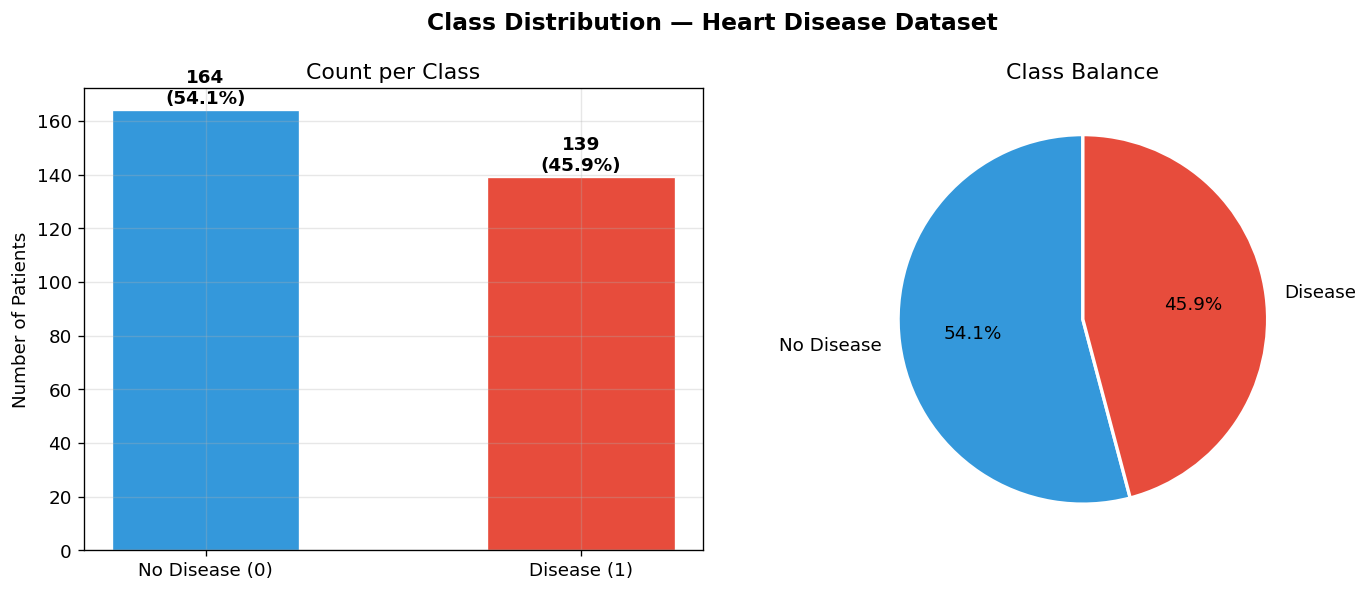

Saved: ../screenshots/eda_class_distribution.png


In [18]:
# Target variable distribution (checks for class imbalance) 
print("=" * 40)
print("TARGET / CLASS DISTRIBUTION")
print("=" * 40)

class_counts = df["target"].value_counts()
class_pct = df["target"].value_counts(normalize=True) * 100

print(f"  No Heart Disease (0): {class_counts[0]} samples ({class_pct[0]:.1f}%)")
print(f"  Heart Disease    (1): {class_counts[1]} samples ({class_pct[1]:.1f}%)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Class Distribution — Heart Disease Dataset", fontsize=14, fontweight="bold")

# Bar chart
colors = ["#3498db", "#e74c3c"]
bars = axes[0].bar(
    ["No Disease (0)", "Disease (1)"],
    class_counts.values,
    color=colors, edgecolor="white", linewidth=0.8, width=0.5
)
axes[0].set_ylabel("Number of Patients")
axes[0].set_title("Count per Class")
for bar, count, pct in zip(bars, class_counts.values, class_pct.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{count}\n({pct:.1f}%)",
        ha="center", va="bottom", fontweight="bold"
    )

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=["No Disease", "Disease"],
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Class Balance")

plt.tight_layout()
plt.savefig(f"{SCREENSHOTS_DIR}/eda_class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {SCREENSHOTS_DIR}/eda_class_distribution.png")

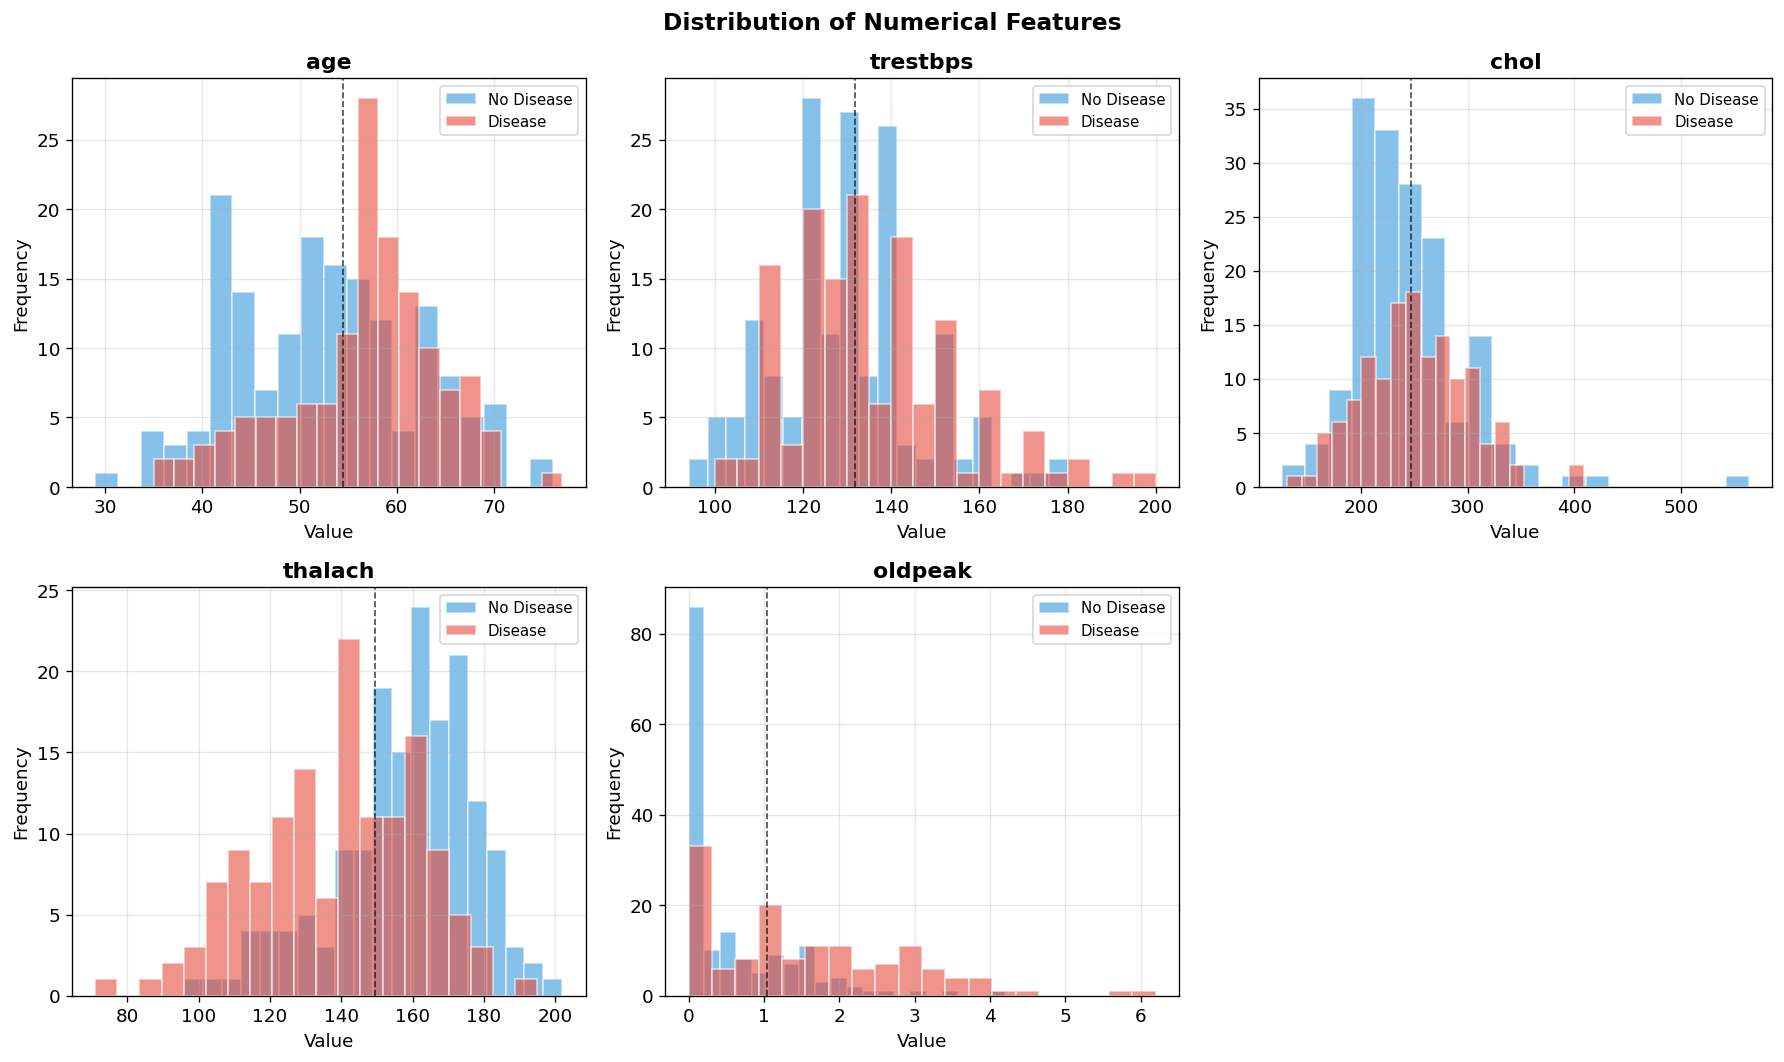

Saved: ../screenshots/eda_numerical_histograms.png


In [19]:
# Numerical features analysis (histograms) 
numerical_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Distribution of Numerical Features", fontsize=14, fontweight="bold")
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    # Split by target for comparison
    no_disease = df[df["target"] == 0][col]
    disease    = df[df["target"] == 1][col]

    axes[i].hist(no_disease, bins=20, alpha=0.6, color="#3498db", label="No Disease", edgecolor="white")
    axes[i].hist(disease,    bins=20, alpha=0.6, color="#e74c3c", label="Disease",    edgecolor="white")
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")
    axes[i].legend(fontsize=9)
    axes[i].axvline(df[col].mean(), color="black", linestyle="--", linewidth=1, alpha=0.7, label="Mean")

fig.delaxes(axes[5]) # removing the empty 6th subplot
plt.tight_layout()
plt.savefig(f"{SCREENSHOTS_DIR}/eda_numerical_histograms.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {SCREENSHOTS_DIR}/eda_numerical_histograms.png")

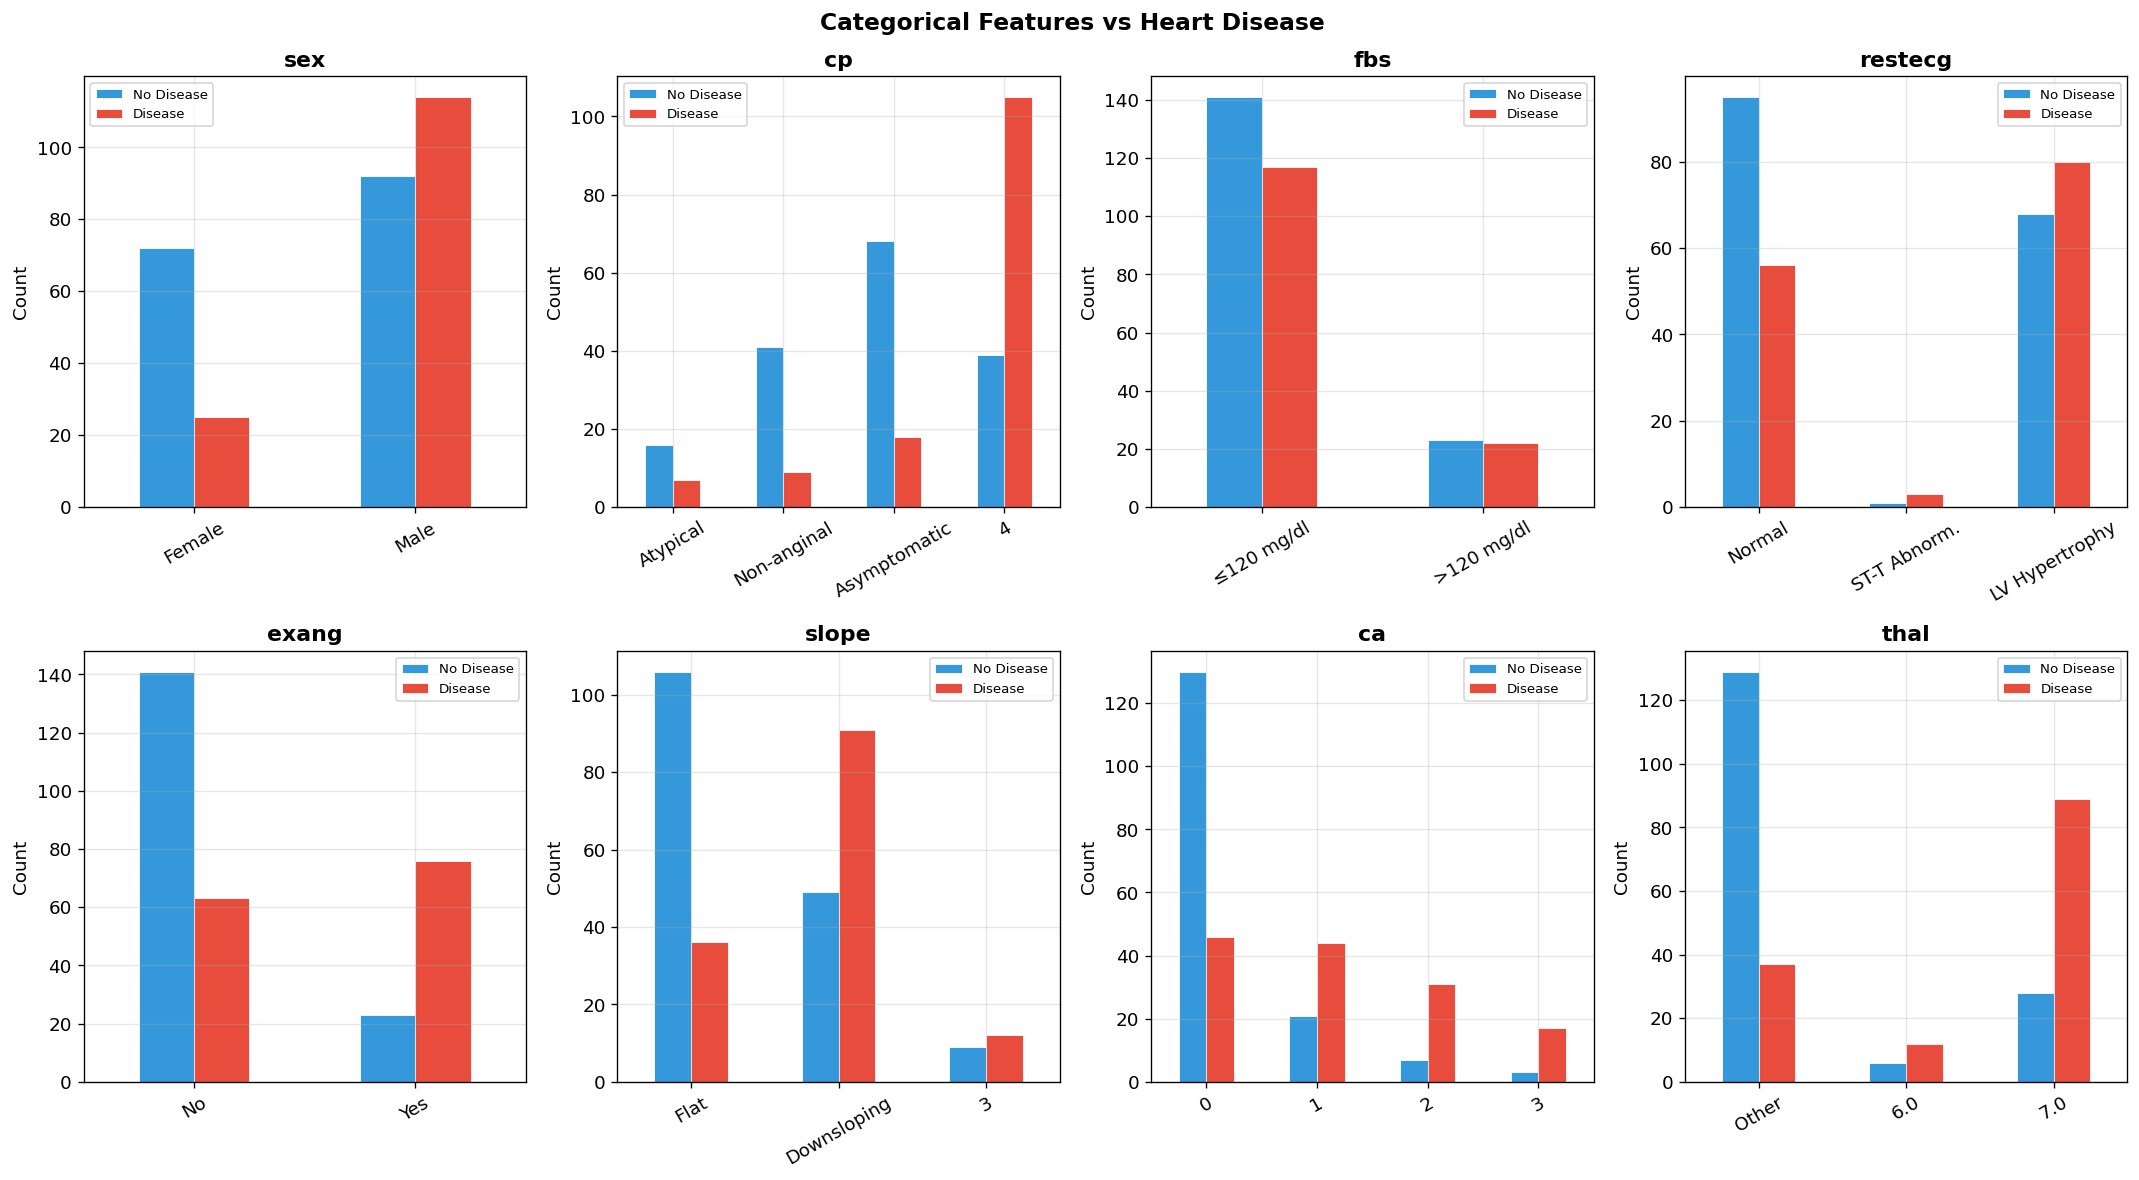

Saved: ../screenshots/eda_categorical_features.png


In [20]:
# Categorical features analysis (bar charts) 
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

cat_labels = {
    "sex":     {0: "Female", 1: "Male"},
    "cp":      {0: "Typical", 1: "Atypical", 2: "Non-anginal", 3: "Asymptomatic"},
    "fbs":     {0: "≤120 mg/dl", 1: ">120 mg/dl"},
    "restecg": {0: "Normal", 1: "ST-T Abnorm.", 2: "LV Hypertrophy"},
    "exang":   {0: "No", 1: "Yes"},
    "slope":   {0: "Upsloping", 1: "Flat", 2: "Downsloping"},
    "ca":      {0: "0", 1: "1", 2: "2", 3: "3", 4: "4"},
    "thal":    {0: "Normal", 1: "Fixed Defect", 2: "Reversible", 3: "Other"},
}

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle("Categorical Features vs Heart Disease", fontsize=14, fontweight="bold")
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    ct = pd.crosstab(df[col], df["target"])
    ct.columns = ["No Disease", "Disease"]

    # Rename index if mapping exists
    if col in cat_labels:
        ct.index = [cat_labels[col].get(idx, str(idx)) for idx in ct.index]

    ct.plot(kind="bar", ax=axes[i], color=["#3498db", "#e74c3c"],
            edgecolor="white", linewidth=0.5)
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{SCREENSHOTS_DIR}/eda_categorical_features.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {SCREENSHOTS_DIR}/eda_categorical_features.png")

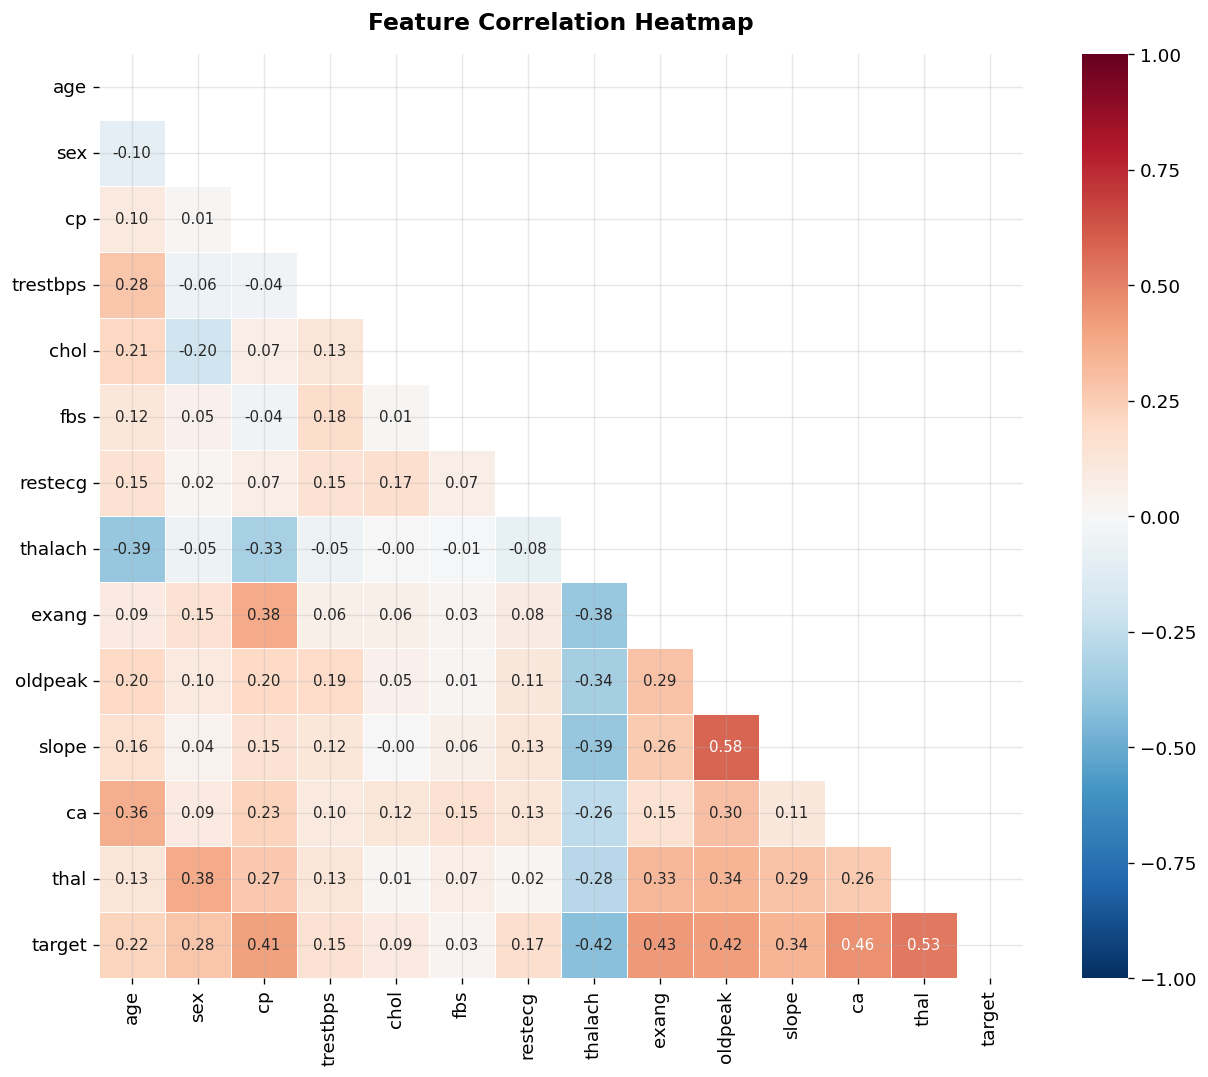

Saved: ../screenshots/eda_correlation_heatmap.png

Top correlations with TARGET:
  thal        : 0.530 ↑
  ca          : 0.460 ↑
  exang       : 0.430 ↑
  thalach     : 0.420 ↓
  oldpeak     : 0.420 ↑
  cp          : 0.410 ↑
  slope       : 0.340 ↑
  sex         : 0.280 ↑
  age         : 0.220 ↑
  restecg     : 0.170 ↑
  trestbps    : 0.150 ↑
  chol        : 0.090 ↑
  fbs         : 0.030 ↑


In [21]:
# correlation analysis
fig, ax = plt.subplots(figsize=(11, 9))

corr_matrix = df.corr(numeric_only=True).round(2)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 9},
)
ax.set_title("Feature Correlation Heatmap", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(f"{SCREENSHOTS_DIR}/eda_correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {SCREENSHOTS_DIR}/eda_correlation_heatmap.png")

print("\nTop correlations with TARGET:")
target_corr = corr_matrix["target"].drop("target").abs().sort_values(ascending=False)
for feat, val in target_corr.items():
    direction = "↑" if corr_matrix.loc[feat, "target"] > 0 else "↓"
    print(f"  {feat:<12}: {val:.3f} {direction}")

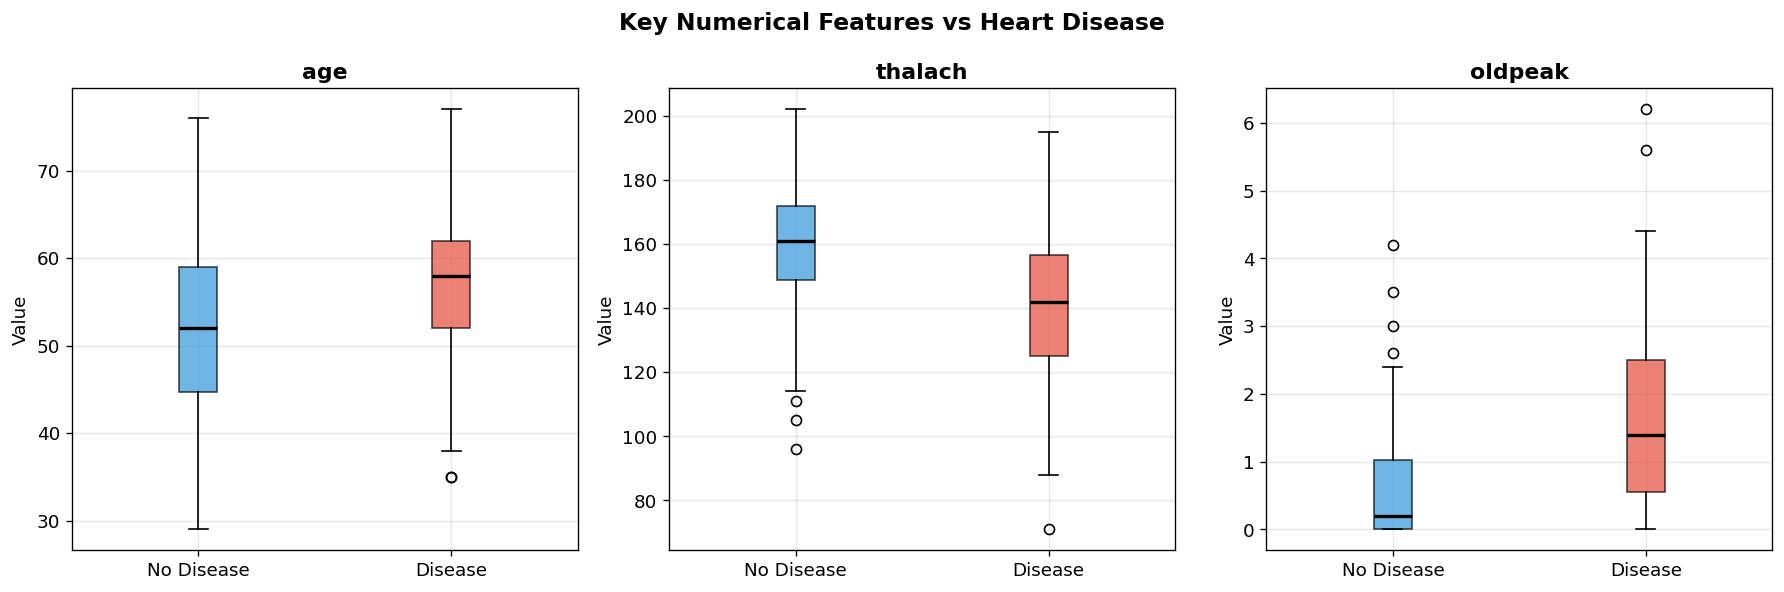

Saved: ../screenshots/eda_boxplots.png


In [23]:
# features relationship with target variable
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Key Numerical Features vs Heart Disease", fontsize=14, fontweight="bold")

key_features = ["age", "thalach", "oldpeak"]
colors = [["#3498db", "#e74c3c"]] * 3

for i, col in enumerate(key_features):
    data_groups = [
        df[df["target"] == 0][col].dropna(),
        df[df["target"] == 1][col].dropna()
    ]
    bp = axes[i].boxplot(
        data_groups,
        labels=["No Disease", "Disease"],
        patch_artist=True,
        medianprops={"color": "black", "linewidth": 2},
    )
    bp["boxes"][0].set_facecolor("#3498db")
    bp["boxes"][1].set_facecolor("#e74c3c")
    for patch in bp["boxes"]:
        patch.set_alpha(0.7)
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_ylabel("Value")

plt.tight_layout()
plt.savefig(f"{SCREENSHOTS_DIR}/eda_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {SCREENSHOTS_DIR}/eda_boxplots.png")

In [24]:
# Summary of EDA analysis
print("=" * 40)
print("EDA SUMMARY — KEY RESULTS")
print("=" * 40)

print(f"""
Dataset
  • {df.shape[0]} patients, {df.shape[1]} features (13 + 1 target)
  • No missing values (or very few in ca/thal)

Class Balance
  • No Disease (0): {class_counts.get(0, 0)} ({class_pct.get(0, 0):.1f}%)
  • Disease    (1): {class_counts.get(1, 0)} ({class_pct.get(1, 0):.1f}%)
  • Fairly balanced — no need for aggressive oversampling

Top Predictive Features (correlation with target)
  • thalach  (max heart rate)   — negative correlation: LOWER rate → disease
  • cp       (chest pain type)  — asymptomatic type strongly linked to disease
  • oldpeak  (ST depression)    — higher → more likely disease
  • exang    (exercise angina)  — presence → more likely disease
  • ca       (vessel count)     — more vessels colored → more likely disease

Preprocessing Decisions (informs Step 2)
  • Numerical features: StandardScaler (age, trestbps, chol, thalach, oldpeak)
  • Categorical features: OneHotEncoder (sex, cp, fbs, restecg, exang, slope, ca, thal)
  • Imputation: median for numerics, most_frequent for categoricals
""")

print("EDA complete. All plots saved to screenshots/")
print("Next step: src/pipeline/train.py (model training)")


EDA SUMMARY — KEY RESULTS

Dataset
  • 303 patients, 14 features (13 + 1 target)
  • No missing values (or very few in ca/thal)

Class Balance
  • No Disease (0): 164 (54.1%)
  • Disease    (1): 139 (45.9%)
  • Fairly balanced — no need for aggressive oversampling

Top Predictive Features (correlation with target)
  • thalach  (max heart rate)   — negative correlation: LOWER rate → disease
  • cp       (chest pain type)  — asymptomatic type strongly linked to disease
  • oldpeak  (ST depression)    — higher → more likely disease
  • exang    (exercise angina)  — presence → more likely disease
  • ca       (vessel count)     — more vessels colored → more likely disease

Preprocessing Decisions (informs Step 2)
  • Numerical features: StandardScaler (age, trestbps, chol, thalach, oldpeak)
  • Categorical features: OneHotEncoder (sex, cp, fbs, restecg, exang, slope, ca, thal)
  • Imputation: median for numerics, most_frequent for categoricals

EDA complete. All plots saved to screenshots/